# Alpamayo-R1 Demo

This notebook will load some example data from the NVIDIA [PhysicalAI-AV Dataset](https://huggingface.co/datasets/nvidia/PhysicalAI-Autonomous-Vehicles) and run the Alpamayo-R1 model on it, producing and visualizing output trajectories and associated reasoning traces.

In [37]:
import copy
import numpy as np
import mediapy as mp
import pandas as pd

import torch
from alpamayo_r1.models.alpamayo_r1 import AlpamayoR1
from alpamayo_r1.load_physical_aiavdataset import load_physical_aiavdataset
from alpamayo_r1 import helper

### Load model and construct data preprocessor

In [38]:
model = AlpamayoR1.from_pretrained("nvidia/Alpamayo-R1-10B", dtype=torch.bfloat16).to("cuda")
processor = helper.get_processor(model.tokenizer)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

### Load and prepare data

In [39]:
import time

t_start_load = time.perf_counter()
clip_ids = pd.read_parquet("clip_ids.parquet")["clip_id"].tolist()
clip_id = clip_ids[650]
# clip_id = '030c760c-ae38-49aa-9ad8-f5650a545d26'

data = load_physical_aiavdataset(clip_id)

messages = helper.create_message(data["image_frames"].flatten(0, 1))

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=False,
    continue_final_message=True,
    return_dict=True,
    return_tensors="pt",
)
print("seq length:", inputs.input_ids.shape)
model_inputs = {
    "tokenized_data": inputs,
    "ego_history_xyz": data["ego_history_xyz"],
    "ego_history_rot": data["ego_history_rot"],
}
model_inputs = helper.to_device(model_inputs, "cuda")
if torch.cuda.is_available():
    torch.cuda.synchronize()
t_end_load = time.perf_counter()
timing_load_ms = (t_end_load - t_start_load) * 1000.0
print(f"数据加载与预处理耗时: {timing_load_ms:.2f} ms")

seq length: torch.Size([1, 3006])
数据加载与预处理耗时: 6157.44 ms


### Model inference

In [40]:
if torch.cuda.is_available():
    torch.cuda.synchronize()

torch.cuda.manual_seed_all(42)
with torch.autocast("cuda", dtype=torch.bfloat16):
    t_start_infer = time.perf_counter()
    pred_xyz, pred_rot, extra = model.sample_trajectories_from_data_with_vlm_rollout(
        data=copy.deepcopy(model_inputs),
        top_p=0.98,
        temperature=0.6,
        num_traj_samples=1,  # Feel free to raise this for more output trajectories and CoC traces.
        max_generation_length=256,
        return_extra=True,
    )

if torch.cuda.is_available():
    torch.cuda.synchronize()
t_end_infer = time.perf_counter()
timing_infer_ms = (t_end_infer - t_start_infer) * 1000.0
timing_cot_ms = float(
    extra.get("timing_cot_ms", float(extra.get("timing_cot_s", float("nan"))) * 1000.0)
)
timing_vision_ms = float(extra.get("timing_vision_ms", float("nan")))
timing_traj_gen_ms = float(
    extra.get(
        "timing_traj_gen_ms",
        float(extra.get("timing_traj_gen_s", float("nan"))) * 1000.0,
    )
)

# the size is [batch_size, num_traj_sets, num_traj_samples]
print("Chain-of-Causation (per trajectory):\n", extra["cot"][0])
print("\n=== 耗时统计 ===")
print(f"数据加载与预处理: {timing_load_ms:.2f} ms")
print(f"Vision Encoder:   {timing_vision_ms:.2f} ms")
print(f"CoT 推理:         {timing_cot_ms:.2f} ms")
print(f"轨迹生成:         {timing_traj_gen_ms:.2f} ms")
print(f"模型推理总耗时:   {timing_infer_ms:.2f} ms")

Chain-of-Causation (per trajectory):
 [['Nudge left to increase clearance from the construction sign encroaching into the lane.']]

=== 耗时统计 ===
数据加载与预处理: 6157.44 ms
Vision Encoder:   99.05 ms
CoT 推理:         667.05 ms
轨迹生成:         103.90 ms
模型推理总耗时:   783.36 ms


## Visualizing data and results

,,,
,,,
,,,
,,,

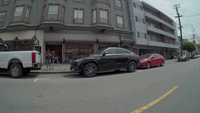
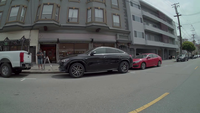
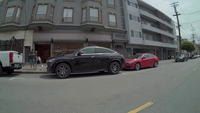
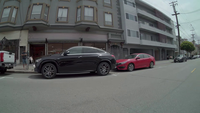
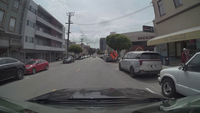
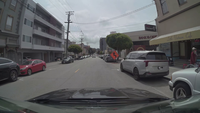
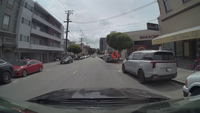
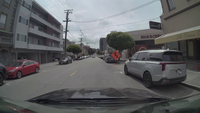
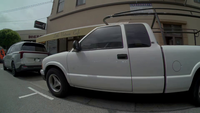
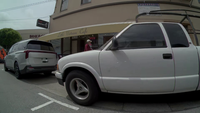
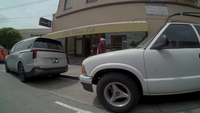
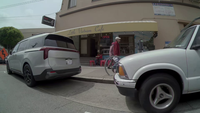
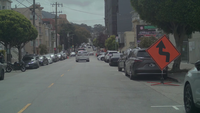
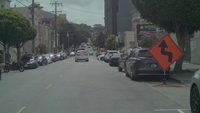
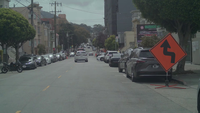
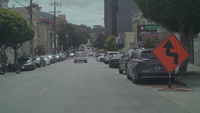

In [41]:
mp.show_images(data["image_frames"].flatten(0, 1).permute(0, 2, 3, 1), columns=4, width=200)

(np.float64(-1.3370180949568748),
 np.float64(0.06907468289136887),
 np.float64(-1.516217201948166),
 np.float64(47.34175023436546))

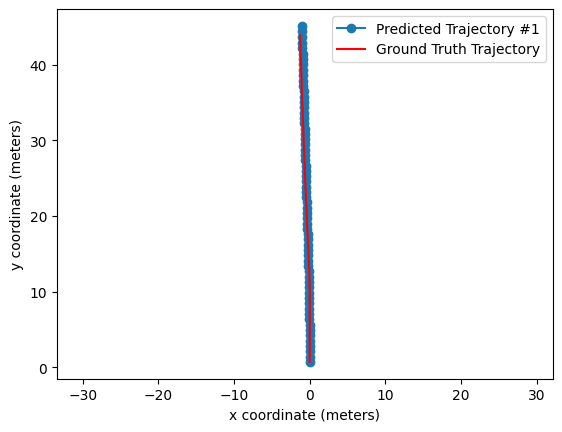

In [42]:
import matplotlib.pyplot as plt


def rotate_90cc(xy):
    # Rotate (x, y) by 90 deg CCW -> (y, -x)
    return np.stack([-xy[1], xy[0]], axis=0)


for i in range(pred_xyz.shape[2]):
    pred_xy = pred_xyz.cpu()[0, 0, i, :, :2].T.numpy()
    pred_xy_rot = rotate_90cc(pred_xy)
    gt_xy = data["ego_future_xyz"].cpu()[0, 0, :, :2].T.numpy()
    gt_xy_rot = rotate_90cc(gt_xy)
    plt.plot(*pred_xy_rot, "o-", label=f"Predicted Trajectory #{i + 1}")
plt.ylabel("y coordinate (meters)")
plt.xlabel("x coordinate (meters)")
plt.plot(*gt_xy_rot, "r-", label="Ground Truth Trajectory")
plt.legend(loc="best")
plt.axis("equal")

In [43]:
pred_xy = pred_xyz.cpu().numpy()[0, 0, :, :, :2].transpose(0, 2, 1)
diff = np.linalg.norm(pred_xy - gt_xy[None, ...], axis=1).mean(-1)
print("minADE:", diff.min(), "meters")

minADE: 0.57225513 meters
